In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [3]:
data_str = 'vin_pax_zyx_act'
pro_str = 'pax_front_lossnorm_loadercorrected'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim_array = [4,5,6,7,8,9,10,12,14,16,18,20,22,24,26,28,30,32]
BN_flag = True
dropout_flag = True
epochs = int(10000)
lr = 1e-4
eps = 3
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 1

dir_list = [
    '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521',  # label 0
    '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532',  # label 1   
    ]


In [4]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)



/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/dataset.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


In [5]:
total_sum_sq = 0.0
total_sum = 0.0
n_total = 0

for images, _ in whole_data_loader:
    images = images.to(torch.float32)
    total_sum += (images).sum().item()
    total_sum_sq += (images ** 2).sum().item()
    n_total += images.numel()

mean_square = total_sum_sq / n_total
mean = total_sum / n_total
print("Mean square of all pixels:", mean_square)

joblib.dump(mean_square,'../results/pax_front_mean_square.pkl')

Mean square of all pixels: 0.03821642352497183


['../results/pax_front_mean_square.pkl']

In [ ]:
train_loss_across_latentdim = []
val_loss_across_latentdim = []

for  latent_dim in latent_dim_array:
        
    now = datetime.now()

    time_str = now.strftime("%Y%m%d_%H%M")

    result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
    os.makedirs(result_dir, exist_ok=True)

    # Train AE
    ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

    ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)

    train_loss_across_latentdim.append(train_losses[-1])
    val_loss_across_latentdim.append(val_losses[-1])
    
    latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

    if isinstance(group_id, torch.Tensor):
        group_id = group_id.cpu().numpy()
    elif isinstance(group_id, list):
        group_id = torch.cat(group_id).cpu().numpy()

    latents_2d = UMAP_train(latents, result_dir)

    DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latents, eps=eps, min_samples=min_samples, result_dir=result_dir)

    kmeans, kmeans_labels = kmeans_cluster(latents, num_clusters=kmeans_num_clusters, result_dir=result_dir)

    fig = umap_2Dplot(latents_2d, 0,1,group_id)
    fig.savefig(os.path.join(result_dir, 'umap_2d_grouplabels.png'))

    fig = cluster_2Dplot(latents, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_latent01_labels.png'))
    
    fig = cluster_2Dplot(latents, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_latent01_labels.png'))

    fig = cluster_2Dplot(latents_2d, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_umap2d_labels.png'))
    
    fig = cluster_2Dplot(latents_2d, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_umap2d_labels.png'))


Epoch 200/10000, Train Loss: 0.3132, Val Loss: 0.3475
Epoch 400/10000, Train Loss: 0.2862, Val Loss: 0.3695
Epoch 600/10000, Train Loss: 0.2719, Val Loss: 0.3847
Epoch 800/10000, Train Loss: 0.2618, Val Loss: 0.3948
Epoch 1000/10000, Train Loss: 0.2561, Val Loss: 0.3999
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0058, max: 0.8792, mean: 0.1258, std: 0.1081
Epoch 1200/10000, Train Loss: 0.2499, Val Loss: 0.4036
Epoch 1400/10000, Train Loss: 0.2451, Val Loss: 0.4071
Epoch 1600/10000, Train Loss: 0.2414, Val Loss: 0.4117
Epoch 1800/10000, Train Loss: 0.2369, Val Loss: 0.4183
Epoch 2000/10000, Train Loss: 0.2359, Val Loss: 0.4176
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0054, max: 0.9007, mean: 0.1243, std: 0.1130
Epoch 2200/10000, Train Loss: 0.2328, Val Loss: 0.4194
Epoch 2400/10000, Train Loss: 0.2288, Val Loss: 0.4219
Epoch 2600/10000, Train Loss: 0.2269, Val Loss: 0.4236
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.2879, Val Loss: 0.3218
Epoch 400/10000, Train Loss: 0.2577, Val Loss: 0.3421
Epoch 600/10000, Train Loss: 0.2374, Val Loss: 0.3578
Epoch 800/10000, Train Loss: 0.2262, Val Loss: 0.3692
Epoch 1000/10000, Train Loss: 0.2181, Val Loss: 0.3751
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0046, max: 0.8960, mean: 0.1250, std: 0.1104
Epoch 1200/10000, Train Loss: 0.2108, Val Loss: 0.3785
Epoch 1400/10000, Train Loss: 0.2056, Val Loss: 0.3855
Epoch 1600/10000, Train Loss: 0.1997, Val Loss: 0.3879
Epoch 1800/10000, Train Loss: 0.1969, Val Loss: 0.3943
Epoch 2000/10000, Train Loss: 0.1943, Val Loss: 0.3953
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0072, max: 0.9366, mean: 0.1284, std: 0.1126
Epoch 2200/10000, Train Loss: 0.1907, Val Loss: 0.3968
Epoch 2400/10000, Train Loss: 0.1869, Val Loss: 0.4009
Epoch 2600/10000, Train Loss: 0.1836, Val Loss: 0.4029
Epoch 2

/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/autoencoders.py:97: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))


Epoch 5200/10000, Train Loss: 0.1610, Val Loss: 0.4226
Epoch 5400/10000, Train Loss: 0.1615, Val Loss: 0.4252
Epoch 5600/10000, Train Loss: 0.1588, Val Loss: 0.4237
Epoch 5800/10000, Train Loss: 0.1578, Val Loss: 0.4214
Epoch 6000/10000, Train Loss: 0.1579, Val Loss: 0.4287
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0017, max: 0.9497, mean: 0.1254, std: 0.1165
Epoch 6200/10000, Train Loss: 0.1571, Val Loss: 0.4293
Epoch 6400/10000, Train Loss: 0.1561, Val Loss: 0.4284
Epoch 6600/10000, Train Loss: 0.1561, Val Loss: 0.4305
Epoch 6800/10000, Train Loss: 0.1553, Val Loss: 0.4327
Epoch 7000/10000, Train Loss: 0.1549, Val Loss: 0.4284
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0017, max: 0.9673, mean: 0.1253, std: 0.1168
Epoch 7200/10000, Train Loss: 0.1544, Val Loss: 0.4306
Epoch 7400/10000, Train Loss: 0.1531, Val Loss: 0.4309
Epoch 7600/10000, Train Loss: 0.1543, Val Loss: 0.4330
Epo

...

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.1427, Val Loss: 0.1599
Epoch 400/10000, Train Loss: 0.1167, Val Loss: 0.1691
Epoch 600/10000, Train Loss: 0.1037, Val Loss: 0.1799
Epoch 800/10000, Train Loss: 0.0955, Val Loss: 0.1861
Epoch 1000/10000, Train Loss: 0.0915, Val Loss: 0.1902
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0019, max: 0.9357, mean: 0.1239, std: 0.1236
Epoch 1200/10000, Train Loss: 0.0871, Val Loss: 0.1932
Epoch 1400/10000, Train Loss: 0.0865, Val Loss: 0.1955
Epoch 1600/10000, Train Loss: 0.0823, Val Loss: 0.1996
Epoch 1800/10000, Train Loss: 0.0810, Val Loss: 0.2047
Epoch 2000/10000, Train Loss: 0.0798, Val Loss: 0.2013
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0010, max: 0.9208, mean: 0.1189, std: 0.1202
Epoch 2200/10000, Train Loss: 0.0788, Val Loss: 0.2048
Epoch 2400/10000, Train Loss: 0.0813, Val Loss: 0.2041
Epoch 2600/10000, Train Loss: 0.0770, Val Loss: 0.2062
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.1340, Val Loss: 0.1545
Epoch 400/10000, Train Loss: 0.1134, Val Loss: 0.1642
Epoch 600/10000, Train Loss: 0.1024, Val Loss: 0.1739
Epoch 800/10000, Train Loss: 0.0946, Val Loss: 0.1798
Epoch 1000/10000, Train Loss: 0.0923, Val Loss: 0.1856
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0018, max: 0.9499, mean: 0.1247, std: 0.1237
Epoch 1200/10000, Train Loss: 0.0873, Val Loss: 0.1890
Epoch 1400/10000, Train Loss: 0.0845, Val Loss: 0.1956
Epoch 1600/10000, Train Loss: 0.0814, Val Loss: 0.1948
Epoch 1800/10000, Train Loss: 0.0804, Val Loss: 0.1993
Epoch 2000/10000, Train Loss: 0.0791, Val Loss: 0.1988
Input stats — min: 0.0000, max: 0.9486, mean: 0.1284, std: 0.1561
Reconstruction stats — min: 0.0014, max: 0.9245, mean: 0.1196, std: 0.1176
Epoch 2200/10000, Train Loss: 0.0783, Val Loss: 0.2020
Epoch 2400/10000, Train Loss: 0.0772, Val Loss: 0.2046
Epoch 2600/10000, Train Loss: 0.0778, Val Loss: 0.2071
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
min(val_losses)

0.07473411994914596

In [ ]:
joblib.dump(train_loss_across_latentdim, os.path.join('../results', 'train_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
joblib.dump(val_loss_across_latentdim, os.path.join('../results', 'val_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
    

['../results/val_loss_across_latentdimpax_front_lossnorm_ch1_ps32_latdim_24_20251003_0622.pkl']

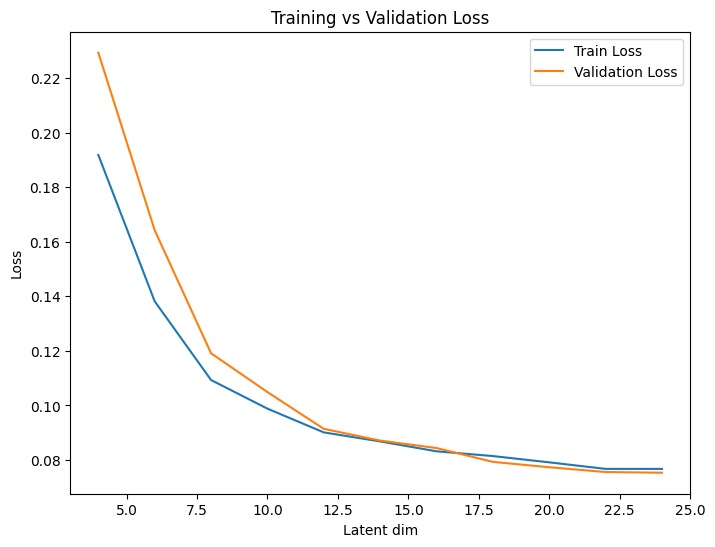

In [ ]:
# Plot training and validation loss
fig = plt.figure(figsize=(8, 6))
plt.plot(latent_dim_array, train_loss_across_latentdim, label='Train Loss')
plt.plot(latent_dim_array, val_loss_across_latentdim, label='Validation Loss')
plt.xlabel('Latent dim')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
fig.savefig(os.path.join('../results', 'latent_dim_train_val_losses'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.png'))